In [4]:
# imports:
from rosbags.rosbag2 import Reader  # this is actually a MARV library
from rosbags.serde import deserialize_cdr
from rosbags.typesys import Stores, get_typestore, get_types_from_msg, TypesysError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitstring import BitArray
import os


In [11]:
# global settings:
path="./"  # for saving plots
rosbag_dir="/media/markus/Extreme_SSD/rosbags/Livox_HAP_driver_investigation/rosbag2_2025_08_25-19_57_49"

topic = "/livox/lidar_192_168_43_117"  # this topic has PoinCloud2 message format, but custom pointfield

typestore = get_typestore(Stores.ROS2_HUMBLE)

In [13]:
def interpret_point_flags(df: pd.DataFrame, col: str, little_endianness: bool = True):
    """
    TODO: write this
    """

    ''' manual: the messages are serialized using little-endian encoding '''
    
    names = ["reserved", "line_idx", "beam_idx", "peak_idx", "face_idx", "point_type"]
    bits = [8,8,4,2,4,6]  # this is the encoding found in Table 21
    for row in range(len(df)):
        if little_endianness:
            #print(row, col)
            le = BitArray(uintle=df.loc[row, col], length=32)
            j = 0
            for i in range(len(names)):
                df.loc[row, names[i]] = le[j:j+bits[i]].uint
                j += bits[i]
        else:    
            be = BitArray(uintbe=df.loc[row, col], length=32)
            j = 0
            for i in range(len(names)):
                df.loc[row, names[i]] = be[j:j+bits[i]].uint
                j += bits[i]

In [28]:
# decode motion-compensated point cloud

def decode_compensated_pc(msg):
    """
    decode the motion-compensated pointcloud msg 
    Note: Actually egomotion compensation is turned off in our sensor configuration)
    """
    # check the definition of the pointFields array to know how the data is structured
    print("\n   - Content of the PointFields array:")
    print(*msg.fields, sep='\n')

    data = np.frombuffer(msg.data, dtype=np.uint8).reshape((-1, msg.point_step))
    print(f"data.shape = {data.shape}")
    x = np.frombuffer(np.ascontiguousarray(data[:, :4]), dtype=np.float32)
    y = np.frombuffer(np.ascontiguousarray(data[:, 4:8]), dtype=np.float32)
    z = np.frombuffer(np.ascontiguousarray(data[:, 8:12]), dtype=np.float32)
    time_offset_ns = np.frombuffer(np.ascontiguousarray(data[:, 12:16]), dtype=np.uint32)
    theta = np.frombuffer(np.ascontiguousarray(data[:, 16:20]), dtype=np.float32)
    phi = np.frombuffer(np.ascontiguousarray(data[:, 20:24]), dtype=np.float32)
    r = np.frombuffer(np.ascontiguousarray(data[:, 24:28]), dtype=np.float32)
    reflectivity = np.frombuffer(np.ascontiguousarray(data[:, 28:32]), dtype=np.float32)
    livox_tag = np.frombuffer(np.ascontiguousarray(data[:, 32:33]), dtype=np.uint8)
    line = np.frombuffer(np.ascontiguousarray(data[:, 33:34]), dtype=np.uint8)

    df = pd.DataFrame({'x': x,
                       'y': y,
                       'z': z,
                       'theta_rad': theta,
                       'phi_rad': phi,
                       'range_m': r,
                       'reflectivity': reflectivity,
                       'time_offset_ns': time_offset_ns,
                       'livox_tag': livox_tag,
                       'line': line})
    
    # here we can check the decoding. there are 4 possibilities: Either input the lsb or the msb, and then choose the endianness.
    #interpret_point_flags(df=df, col="livox_tag", little_endianness=True)

    # calculate spherical coordinates:
    df["azimuth_deg"] = np.rad2deg(df["theta_rad"])
    df["elevation_deg"] = np.rad2deg(df["phi_rad"])

    invalid_points_df = df[df['range_m']==0.0]
    n_invalid_pts = len(invalid_points_df)
    n_valid_pts = len(df)-n_invalid_pts
    n_pts = len(df)
    print(f"number of invalid points={n_invalid_pts}")
    print(f"number of valid points={n_valid_pts}")
    print(f"number of points={n_pts}")
    print(invalid_points_df['livox_tag'].value_counts())
    print(df['livox_tag'].value_counts())

    #print(df.info())
    #print(df.describe())
    #print(df.dtypes)
    return df


In [29]:
def plot_compensated_pc(df, coloring: str = "line"):
    """
    plot motion-compensated point cloud for extracting scanning pattern
    """
    #ax = df.plot.scatter(x="y", y="z", c="b", s=1, figsize=(15,5))
    ax = df.plot.scatter(x="azimuth_deg", y="elevation_deg", c=coloring, s=1, figsize=(15,5))
    ax.set_aspect('equal')
    ax.set_title(f"{coloring} of real Scanning Pattern of Livox HAP")
    ax.set_ylabel("Elevation [deg]")
    ax.set_xlabel("Azimuth [deg]")
    filename = f'{coloring}_of_real_Scanning_Pattern_of_Livox_HAP.png'
    #plt.savefig(os.path.join(path, filename))
    plt.show()

# Decode the message

In [30]:
"""
write the first frame of the compensated_pointcloud in a pandas DataFrame and add the decoded information of the "point_flags"
"""

def filter_connections(connections, topic_names: [str]):
    """
    filters the connections (from rosbags lib) by topic names listed in topic_names list
    """
    filtered_conns = []
    for conn in connections:
        if conn.topic in topic_names:
            filtered_conns.append(conn)

    #print(f"   - Number of filtered connections: {len(filtered_conns)}\n")
    return filtered_conns

with Reader(rosbag_dir) as ros2_reader:

    # get all connections
    ros2_conns = [conn for conn in ros2_reader.connections]
    print(f"1. Number of connections: {len(ros2_conns)}")
    print("-------------------\n")

    # print all topic names, to find out which topic we need to inspect
    print(f"2. The {len(ros2_conns)} Topic Names:")
    print(*[conn.topic for conn in ros2_conns], sep='\n')
    print("-------------------\n")

    print("4. Visualize Data:")
    # filter the connections for those topics that we are interested in
    pc_connections = filter_connections(ros2_conns, [topic])

    messages_of_conns = ros2_reader.messages(connections=pc_connections)

    decoded_pc_df = None
    for m, msg in enumerate(messages_of_conns):
        (connection, timestamp, rawdata) = msg
        if connection.topic == topic:
            print(f"   - Topic name: {connection.topic}") # topic
            print(f"   - Message type name: {connection.msgtype}") # message type (massage type itself is a string)

            # deserialize data and print it
            data = typestore.deserialize_cdr(rawdata, connection.msgtype)
            print(f"   - Number of points in pc according to header-width info: {data.width}")

            # plot the point cloud in 2D
            decoded_pc_df = decode_compensated_pc(data)
            break  # only first frame

1. Number of connections: 8
-------------------

2. The 8 Topic Names:
/initialpose
/clicked_point
/livox/lidar_192_168_43_117
/move_base_simple/goal
/parameter_events
/rosout
/tf
/tf_static
-------------------

4. Visualize Data:
   - Topic name: /livox/lidar_192_168_43_117
   - Message type name: sensor_msgs/msg/PointCloud2
   - Number of points in pc according to header-width info: 44640

   - Content of the PointFields array:
sensor_msgs__msg__PointField(name='x', offset=0, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='y', offset=4, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='z', offset=8, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')

# Plot the Decoding Result

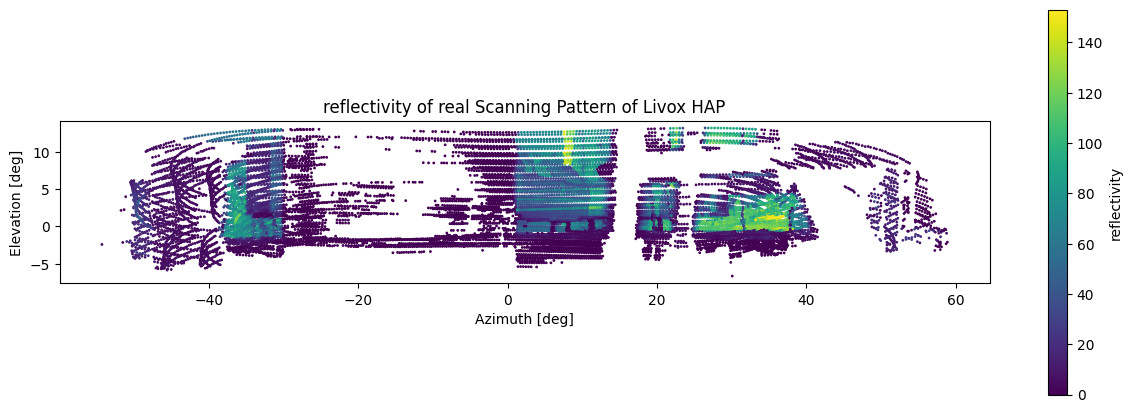

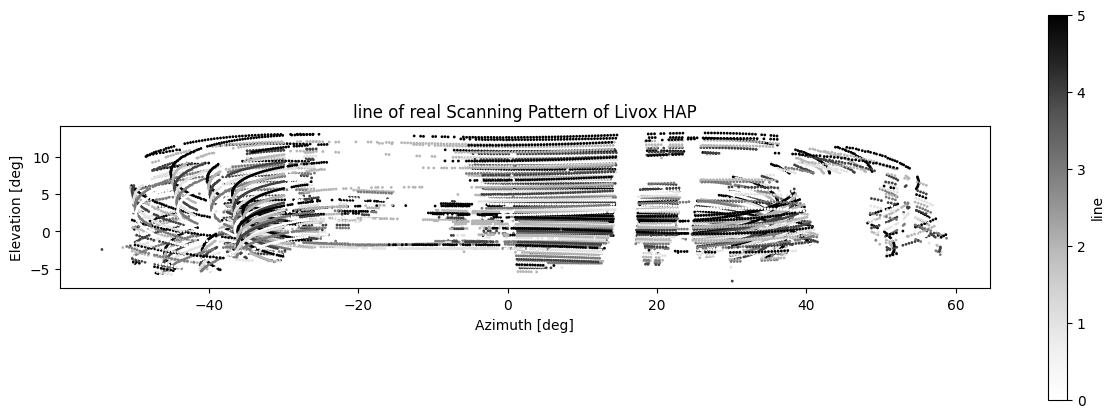

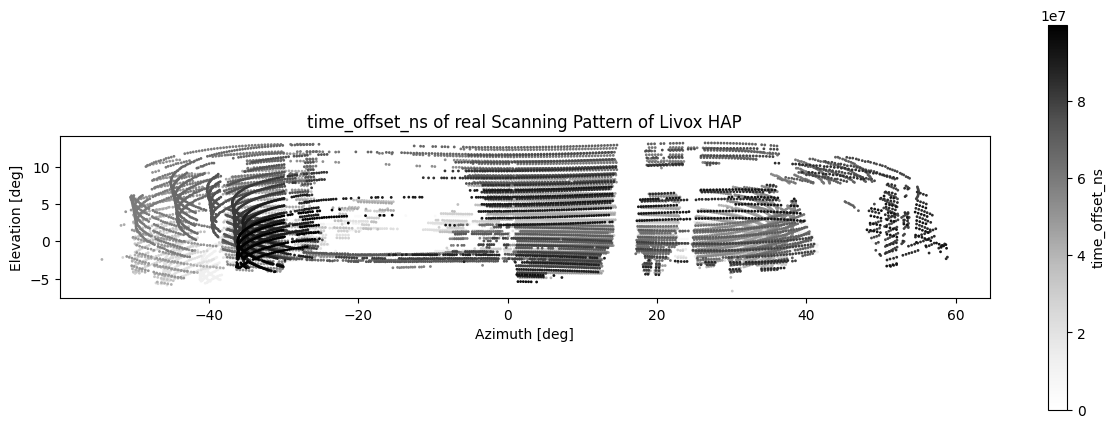

In [18]:
coloring = ["reflectivity", "line", "time_offset_ns"]
for color_idx,color in enumerate(coloring):
    plot_compensated_pc(decoded_pc_df, coloring=color)

# Testing Area for Decoding

In [ ]:
lsb = np.array(37750032, dtype=np.uint32)
msb = np.array(147458, dtype=np.uint32)
print("input:")
print(f"lsb = {lsb}")
print(f"msb = {msb}")
print("\n###########\n")

''' MessageDataFormat_UserManual_p.pdf states on page 3: "the messages are serialized using little-endian encoding" '''

print("lsb")
ne_lsb = BitArray(uintne=lsb, length=32)  # native endian
le_lsb = BitArray(uintle=lsb, length=32)  # little endian
print(f"lsb little endian {le_lsb.uint}")
print(f"lsb little endian {le_lsb.bin}")
be_lsb = BitArray(uintbe=lsb, length=32)  # big endian
print(f"lsb big endian {be_lsb.uint}")
print(f"lsb big endian {be_lsb.bin}")

print("\n###########\n")

print("msb")
ne_msb = BitArray(uintne=msb, length=32)  # native endian
le_msb = BitArray(uintle=msb, length=32)  # little endian
print(f"msb little endian {le_msb.uint}")
print(f"msb little endian {le_msb.bin}")
be_msb = BitArray(uintbe=msb, length=32)  # big endian
print(f"msb big endian {be_msb.uint}")
print(f"msb big endian {be_msb.bin}")

## now we check the four possible interpretations:

print("\n##### interpretations ######\n" )

names = ["reserved", "line_idx", "beam_idx", "peak_idx", "face_idx", "point_type"]
bits = [8,8,4,2,4,6]

print("\n##### interpretations: lsb little endian ######\n" )
j = 0
for i in range(6):
    print(names[i], le_lsb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: lsb big endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], be_lsb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: msb little endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], le_msb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: msb big endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], be_msb[j:j+bits[i]].uint)
    j += bits[i]